# Exploratory Data Analysis and Data Profiling for Yellow Taxi Data

This notebook profiles the uploaded Yellow Taxi Parquet file and is intended only for analysis and rule discovery. It does not clean or transform the data.

## Section 1 - Import Libraries

In [1]:
# Import only the libraries required for profiling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configure display settings for a cleaner notebook experience
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
sns.set_theme(style="whitegrid")

## Section 2 - Load Dataset

In [2]:
# Locate the uploaded Parquet file
# Update this path if the file is stored in a different location.
parquet_candidates = [
    Path('yellow_tripdata_2025-01.parquet'),
    Path('data/yellow_tripdata_2025-01.parquet'),
    Path('datasets/yellow_tripdata_2025-01.parquet'),
    Path('bronze/transactions/yellow_taxi/yellow_tripdata_2025-01.parquet'),
    Path(r'C:/Users/pooji/AppData/Local/Temp/yellow_tripdata_2025-01.parquet'),
]

data_path = None
for candidate in parquet_candidates:
    if candidate.exists():
        data_path = candidate
        break

if data_path is None:
    raise FileNotFoundError('Parquet file not found. Update the file path in this notebook.')

# Load the dataset
df = pd.read_parquet(data_path)

# Display a preview of the dataset
print('Loaded file:', data_path)
print('Shape:', df.shape)
print('\nFirst 5 rows:')
display(df.head())
print('\nLast 5 rows:')
display(df.tail())

Loaded file: C:\Users\pooji\AppData\Local\Temp\yellow_tripdata_2025-01.parquet
Shape: (3475226, 20)

First 5 rows:


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,N,229,237,1,10.0,3.5,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.0
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,N,236,237,1,5.1,3.5,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.0
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,N,141,141,1,5.1,3.5,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.0
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,N,244,244,2,7.2,1.0,0.5,0.00,0.0,1.0,9.70,0.0,0.0,0.0
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,N,244,116,2,5.8,1.0,0.5,0.00,0.0,1.0,8.30,0.0,0.0,0.0



Last 5 rows:


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
3475221,2,2025-01-31 23:01:48,2025-01-31 23:16:29,NaN,3.35,NaN,NaN,79,237,0,15.85,0.0,0.5,0.0,0.0,1.0,20.60,NaN,NaN,0.75
3475222,2,2025-01-31 23:50:29,2025-02-01 00:17:27,NaN,8.73,NaN,NaN,161,116,0,28.14,0.0,0.5,0.0,0.0,1.0,32.89,NaN,NaN,0.75
3475223,2,2025-01-31 23:26:59,2025-01-31 23:43:01,NaN,2.64,NaN,NaN,144,246,0,14.91,0.0,0.5,0.0,0.0,1.0,19.66,NaN,NaN,0.75
3475224,2,2025-01-31 23:14:34,2025-01-31 23:34:52,NaN,3.16,NaN,NaN,142,107,0,17.55,0.0,0.5,0.0,0.0,1.0,22.30,NaN,NaN,0.75
3475225,2,2025-01-31 23:56:42,2025-02-01 00:07:27,NaN,2.29,NaN,NaN,237,238,0,12.09,0.0,0.5,0.0,0.0,1.0,16.09,NaN,NaN,0.00


## Section 3 - Dataset Overview

In [3]:
# Show the schema in a structured way
print('Schema:')
print(df.dtypes.to_string())
print('\nColumn names:')
print(df.columns.tolist())
print('\nMemory usage:')
print(df.memory_usage(deep=True).to_string())
print('\nSummary statistics:')
display(df.describe(include='all').T)

Schema:
VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag                  str
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
cbd_congestion_fee              float64

Column names:
['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_ty

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
VendorID,3475226.0,NaN,NaN,NaN,1.785428,1.0,2.0,2.0,2.0,7.0,0.426328
tpep_pickup_datetime,3475226,NaN,NaN,NaN,2025-01-17 11:02:55.910964,2024-12-31 20:47:55,2025-01-10 07:59:01,2025-01-17 15:41:33,2025-01-24 19:34:06,2025-02-01 00:00:44,NaN
tpep_dropoff_datetime,3475226,NaN,NaN,NaN,2025-01-17 11:17:56.997901,2024-12-18 07:52:40,2025-01-10 08:15:29.500000,2025-01-17 15:59:34,2025-01-24 19:48:31,2025-02-01 23:44:11,NaN
passenger_count,2935077.0,NaN,NaN,NaN,1.297859,0.0,1.0,1.0,1.0,9.0,0.75075
trip_distance,3475226.0,NaN,NaN,NaN,5.855126,0.0,0.98,1.67,3.1,276423.57,564.6016
RatecodeID,2935077.0,NaN,NaN,NaN,2.482535,1.0,1.0,1.0,1.0,99.0,11.632772
store_and_fwd_flag,2935077,2,N,2927431,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PULocationID,3475226.0,NaN,NaN,NaN,165.191576,1.0,132.0,162.0,234.0,265.0,64.529483
DOLocationID,3475226.0,NaN,NaN,NaN,164.125177,1.0,113.0,162.0,234.0,265.0,69.401686
payment_type,3475226.0,NaN,NaN,NaN,1.036623,0.0,1.0,1.0,1.0,5.0,0.701333


The schema and summary statistics provide the first high-level view of the dataset. They help identify the available attributes, their likely types, and the overall spread of numeric values.

## Section 4 - Missing Value Analysis

Missing values by column:


,Missing Values,Missing %
passenger_count,540149,15.54
RatecodeID,540149,15.54
store_and_fwd_flag,540149,15.54
congestion_surcharge,540149,15.54
Airport_fee,540149,15.54


C:\Users\pooji\AppData\Local\Temp\ipykernel_31676\2439476826.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=missing_df.reset_index(), x='index', y='Missing %', palette='viridis')


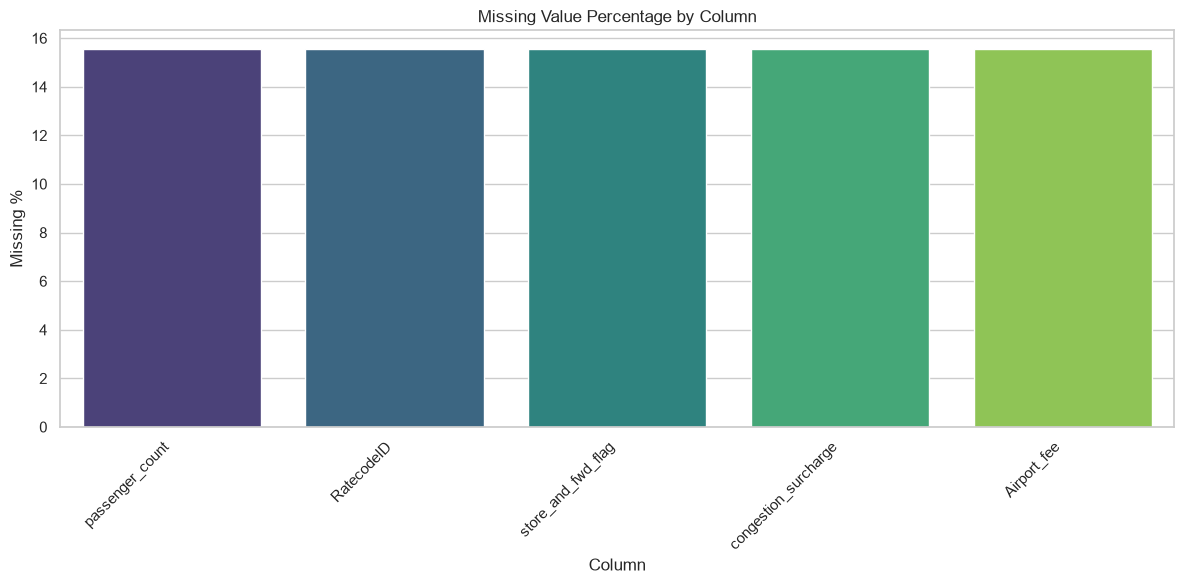

In [4]:
# Calculate missing values and percentage of missing data
missing_values = df.isna().sum()
missing_percent = (df.isna().mean() * 100).round(2)
missing_df = pd.DataFrame({'Missing Values': missing_values, 'Missing %': missing_percent})
missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values('Missing Values', ascending=False)

print('Missing values by column:')
display(missing_df)

# Visualize missing values - use a bar chart instead for large datasets
plt.figure(figsize=(12, 6))
sns.barplot(data=missing_df.reset_index(), x='index', y='Missing %', palette='viridis')
plt.title('Missing Value Percentage by Column')
plt.xlabel('Column')
plt.ylabel('Missing %')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Columns with missing values should be reviewed carefully. In this dataset, some fields appear sparsely populated and may need special handling in the Silver layer.

## Section 5 - Duplicate Analysis

In [5]:
# Check for duplicate rows
duplicate_rows = df.duplicated(keep=False)
duplicate_count = int(duplicate_rows.sum())
print('Duplicate row count:', duplicate_count)

if duplicate_count > 0:
    print('\nExample duplicate records:')
    display(df.loc[duplicate_rows].head(10))
else:
    print('No duplicate rows detected.')

Duplicate row count: 0
No duplicate rows detected.


Duplicate records can distort row counts and downstream metrics. In a production pipeline, duplicates should be monitored and removed if they are true repeats.

## Section 6 - Data Quality Checks

In [6]:
# Create datetime columns for analysis
# This block is for profiling only and does not modify the dataset.
df_profile = df.copy()

# Negative values checks
negative_checks = {
    'fare_amount': (df_profile['fare_amount'] < 0).sum(),
    'trip_distance': (df_profile['trip_distance'] < 0).sum(),
    'tip_amount': (df_profile['tip_amount'] < 0).sum(),
    'tolls_amount': (df_profile['tolls_amount'] < 0).sum(),
    'total_amount': (df_profile['total_amount'] < 0).sum(),
    'extra': (df_profile['extra'] < 0).sum(),
}

print('Negative value counts:')
for col, count in negative_checks.items():
    print(f'{col}: {count}')

# Invalid passenger count
invalid_passenger_count = int((df_profile['passenger_count'] <= 0).sum())
print('\nInvalid passenger_count rows:', invalid_passenger_count)

# Invalid timestamps
invalid_timestamps = int((df_profile['tpep_pickup_datetime'] > df_profile['tpep_dropoff_datetime']).sum())
print('Pickup after dropoff rows:', invalid_timestamps)

# Trip duration calculation
trip_duration_minutes = (df_profile['tpep_dropoff_datetime'] - df_profile['tpep_pickup_datetime']).dt.total_seconds() / 60
negative_duration = int((trip_duration_minutes < 0).sum())
extremely_long_duration = int((trip_duration_minutes > 180).sum())

print('\nTrip duration summary:')
print('Negative duration count:', negative_duration)
print('Duration > 180 minutes count:', extremely_long_duration)
print('Duration p95:', round(trip_duration_minutes.quantile(0.95), 2))
print('Duration p99:', round(trip_duration_minutes.quantile(0.99), 2))

# Check location IDs
missing_pickup_location = int(df_profile['PULocationID'].isna().sum())
missing_dropoff_location = int(df_profile['DOLocationID'].isna().sum())
print('\nMissing PULocationID:', missing_pickup_location)
print('Missing DOLocationID:', missing_dropoff_location)

Negative value counts:
fare_amount: 144118
trip_distance: 0
tip_amount: 124
tolls_amount: 4559
total_amount: 63037
extra: 29596

Invalid passenger_count rows: 24656
Pickup after dropoff rows: 124

Trip duration summary:
Negative duration count: 124
Duration > 180 minutes count: 1377
Duration p95: 36.2
Duration p99: 58.92

Missing PULocationID: 0
Missing DOLocationID: 0


These checks highlight rows that are logically inconsistent or likely invalid. These records should be reviewed before the Silver layer is finalized.

## Section 7 - Outlier Detection

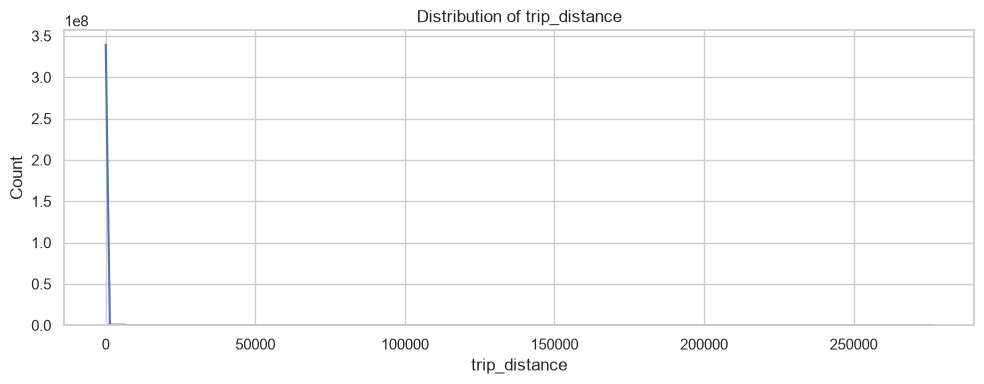

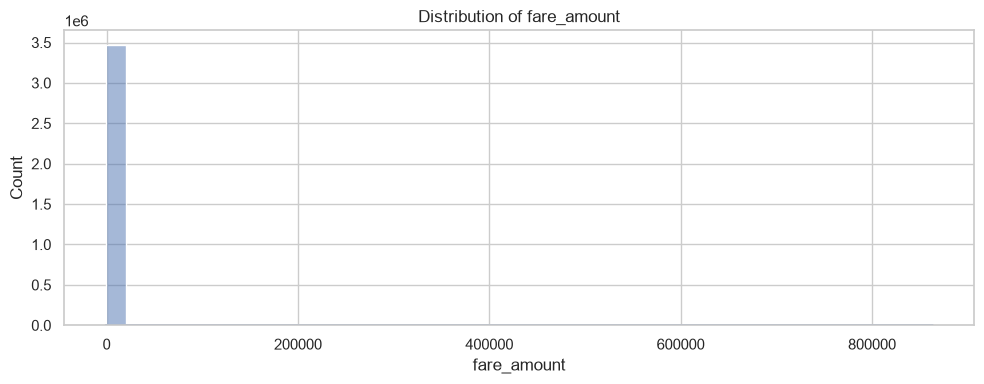

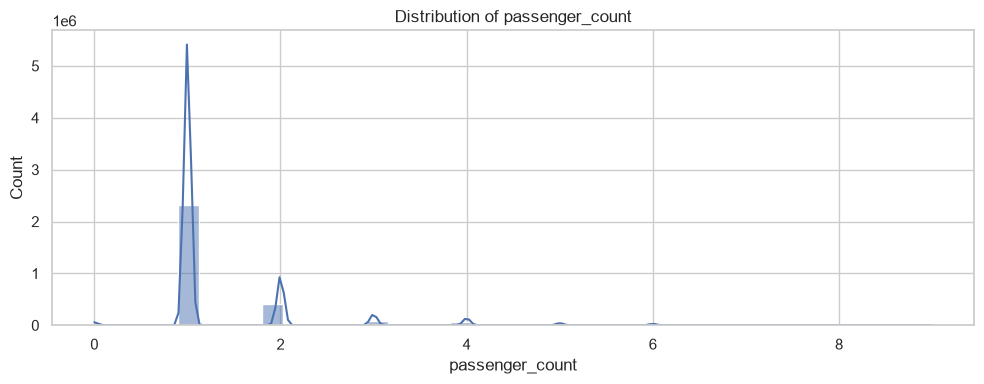

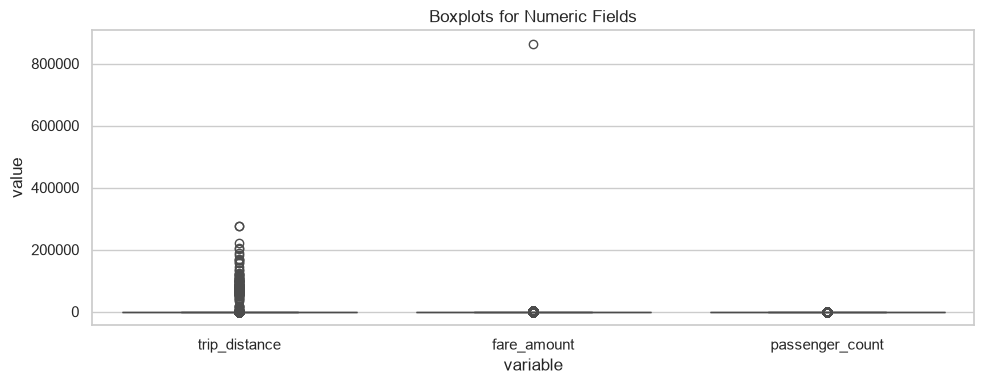

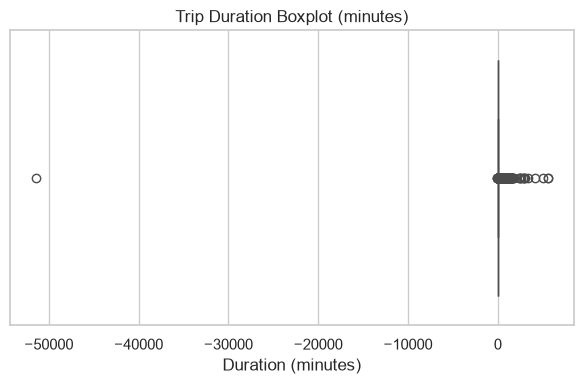

In [7]:
# Visualize distributions of key numeric fields
numeric_columns = ['trip_distance', 'fare_amount', 'passenger_count']

for column in numeric_columns:
    plt.figure(figsize=(10, 4))
    sns.histplot(df_profile[column].dropna(), bins=40, kde=True)
    plt.title(f'Distribution of {column}')
    plt.tight_layout()
    plt.show()

# Boxplots for outlier visibility
plt.figure(figsize=(10, 4))
sns.boxplot(data=df_profile[['trip_distance', 'fare_amount', 'passenger_count']].melt(), x='variable', y='value')
plt.title('Boxplots for Numeric Fields')
plt.tight_layout()
plt.show()

# Trip duration boxplot
plt.figure(figsize=(6, 4))
sns.boxplot(x=trip_duration_minutes.dropna())
plt.title('Trip Duration Boxplot (minutes)')
plt.xlabel('Duration (minutes)')
plt.tight_layout()
plt.show()

The plots help visualize skew and extreme values. They are useful for understanding whether a field is naturally wide or whether a cleaning rule may be needed later.

## Section 8 - Data Type Validation

In [8]:
# Review the current data types and recommended conversions
dtype_summary = pd.DataFrame({
    'Current_dtype': df_profile.dtypes
})
dtype_summary['Recommended_conversion'] = np.nan

for column in ['VendorID', 'PULocationID', 'DOLocationID', 'passenger_count', 'RatecodeID', 'payment_type']:
    dtype_summary['Recommended_conversion'] = dtype_summary['Recommended_conversion'].astype(str)

    for column in ['VendorID', 'PULocationID', 'DOLocationID', 'passenger_count', 'RatecodeID', 'payment_type']:
        dtype_summary.loc[column, 'Recommended_conversion'] = 'integer'

for column in ['trip_distance', 'fare_amount', 'extra', 'tip_amount', 'tolls_amount', 'total_amount', 'mta_tax', 'improvement_surcharge', 'congestion_surcharge', 'Airport_fee', 'cbd_congestion_fee']:
    dtype_summary.loc[column, 'Recommended_conversion'] = 'float'

for column in ['tpep_pickup_datetime', 'tpep_dropoff_datetime']:
    dtype_summary.loc[column, 'Recommended_conversion'] = 'timestamp'

display(dtype_summary)

,Current_dtype,Recommended_conversion
VendorID,int32,integer
tpep_pickup_datetime,datetime64[us],timestamp
tpep_dropoff_datetime,datetime64[us],timestamp
passenger_count,float64,integer
trip_distance,float64,float
RatecodeID,float64,integer
store_and_fwd_flag,str,NaN
PULocationID,int32,integer
DOLocationID,int32,integer
payment_type,int64,integer


The current file already contains datetime-like values, but they should be explicitly validated and cast to timestamp types in the Silver layer for consistency and performance.

## Section 9 - Business Rule Validation

In [9]:
# Inspect categorical and business-related columns
business_columns = ['VendorID', 'RatecodeID', 'payment_type', 'store_and_fwd_flag']

for column in business_columns:
    print(f'\n{column} unique values:')
    print(df_profile[column].dropna().unique()[:20])
    print('Count:', df_profile[column].dropna().nunique())


VendorID unique values:
[1 2 7 6]
Count: 4

RatecodeID unique values:
[ 1.  5. 99.  2.  4.  3.  6.]
Count: 7

payment_type unique values:
[1 2 4 3 5 0]
Count: 6

store_and_fwd_flag unique values:
<ArrowStringArray>
['N', 'Y']
Length: 2, dtype: str
Count: 2


Business-rule columns should be reviewed for unexpected values, but this notebook focuses on profiling rather than enforcing complex business rules.

## Section 10 - Data Quality Report

In [10]:
# Build a clean quality report table for the notebook
quality_report = pd.DataFrame([
    ['Duplicate Rows', duplicate_count, 'Remove', 'High'],
    ['Negative Fare', negative_checks['fare_amount'], 'Remove', 'High'],
    ['Negative Trip Distance', negative_checks['trip_distance'], 'Remove', 'High'],
    ['Invalid Passenger Count', invalid_passenger_count, 'Remove', 'High'],
    ['Pickup After Dropoff', invalid_timestamps, 'Remove', 'High'],
    ['Missing Passenger Count', int(df_profile['passenger_count'].isna().sum()), 'Review/Replace', 'Medium'],
    ['Missing RatecodeID', int(df_profile['RatecodeID'].isna().sum()), 'Review/Replace', 'Medium'],
    ['Missing Store and Forward Flag', int(df_profile['store_and_fwd_flag'].isna().sum()), 'Review/Replace', 'Medium'],
    ['Missing Location IDs', int(df_profile['PULocationID'].isna().sum() + df_profile['DOLocationID'].isna().sum()), 'Remove/Review', 'Medium'],
], columns=['Check', 'Records Affected', 'Recommended Action', 'Priority'])

display(quality_report)

,Check,Records Affected,Recommended Action,Priority
0,Duplicate Rows,0,Remove,High
1,Negative Fare,144118,Remove,High
2,Negative Trip Distance,0,Remove,High
3,Invalid Passenger Count,24656,Remove,High
4,Pickup After Dropoff,124,Remove,High
5,Missing Passenger Count,540149,Review/Replace,Medium
6,Missing RatecodeID,540149,Review/Replace,Medium
7,Missing Store and Forward Flag,540149,Review/Replace,Medium
8,Missing Location IDs,0,Remove/Review,Medium


This summary table provides a concise view of the main issues found during profiling. It can be used as the basis for the Silver-layer cleaning rules.

## Section 11 - Silver Layer Cleaning Rules

In [11]:
# Prepare a simple recommendation summary based on the profiling results
required_transformations = [
    'Remove duplicate rows',
    'Remove rows with nulls in mandatory columns',
    'Remove rows with negative fare_amount',
    'Remove rows with negative trip_distance',
    'Remove rows with passenger_count <= 0',
    'Remove rows where pickup datetime is after dropoff datetime',
    'Cast core numeric columns to appropriate types',
    'Cast datetime columns to timestamp',
    'Create pickup_year and pickup_month from pickup datetime'
]

optional_improvements = [
    'Review extremely long trip durations',
    'Review extremely high trip distances',
    'Review sparse categorical columns such as RatecodeID and store_and_fwd_flag',
    'Consider business-specific validation for payment_type and VendorID categories'
]

print('Required Transformations:')
for item in required_transformations:
    print('-', item)

print('\nOptional Improvements:')
for item in optional_improvements:
    print('-', item)

Required Transformations:
- Remove duplicate rows
- Remove rows with nulls in mandatory columns
- Remove rows with negative fare_amount
- Remove rows with negative trip_distance
- Remove rows with passenger_count <= 0
- Remove rows where pickup datetime is after dropoff datetime
- Cast core numeric columns to appropriate types
- Cast datetime columns to timestamp
- Create pickup_year and pickup_month from pickup datetime

Optional Improvements:
- Review extremely long trip durations
- Review extremely high trip distances
- Review sparse categorical columns such as RatecodeID and store_and_fwd_flag
- Consider business-specific validation for payment_type and VendorID categories
